TASK 2

In [13]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (LeaveOneGroupOut, cross_val_predict, KFold,
                                     permutation_test_score)
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             matthews_corrcoef, make_scorer)
from scipy.stats import ttest_rel, wilcoxon, shapiro, spearmanr, t as tdist, probplot



RNG=0; np.random.seed(RNG)
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":.3})

df = pd.read_csv("HR_data.csv", index_col=0)
print("rows:", len(df), "| individuals:", df.Individual.nunique(),
      "| records/person:", df.Individual.value_counts().unique(),
      "| cohorts:", dict(df.groupby('Cohort').Individual.nunique()))
df.head()

rows: 168 | individuals: 14 | records/person: [12] | cohorts: {'D1_1': np.int64(8), 'D1_2': np.int64(6)}


,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Round,Phase,Individual,Puzzler,Frustrated,Cohort
0,77.965186,78.00,3.345290,73.23,83.37,22924.945,round_3,phase3,1,1,1,D1_1
1,70.981097,70.57,2.517879,67.12,78.22,21930.400,round_3,phase2,1,1,5,D1_1
2,73.371959,73.36,3.259569,67.88,80.22,21647.085,round_3,phase1,1,1,0,D1_1
3,78.916822,77.88,4.054595,72.32,84.92,25258.905,round_2,phase3,1,1,1,D1_1
4,77.322226,74.55,6.047603,70.52,90.15,23890.565,round_2,phase2,1,1,5,D1_1


elevated rate = 0.375  | majority-class baseline = 0.625


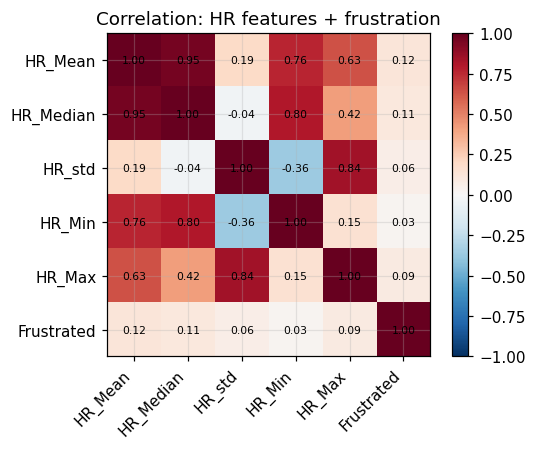

Pearson corr(frustration, feature):
HR_Mean      0.120
HR_Median    0.106
HR_std       0.064
HR_Min       0.026
HR_Max       0.091


In [14]:
feat_cols = ['HR_Mean','HR_Median','HR_std','HR_Min','HR_Max']
X = df[feat_cols].to_numpy()
y = (df.Frustrated > df.Frustrated.median()).astype(int).to_numpy()   # 1 = elevated (>2)
groups  = df.Individual.to_numpy()
cohorts = df.Cohort.to_numpy()

pos = y.mean(); majority = max(pos, 1-pos)
print(f"elevated rate = {pos:.3f}  | majority-class baseline = {majority:.3f}")

# Correlation matrix (features + frustration)
corr = df[feat_cols+['Frustrated']].corr()
fig,ax = plt.subplots(figsize=(5.2,4.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right"); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7)
plt.colorbar(im,fraction=.046); ax.set_title("Correlation: HR features + frustration")
plt.tight_layout(); plt.show()

print("Pearson corr(frustration, feature):")
print(corr['Frustrated'][feat_cols].round(3).to_string())

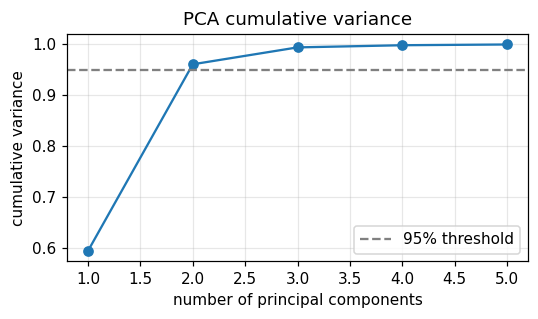

cumulative variance: [0.594 0.961 0.994 0.999 1.   ] ->  2 PCs explain 96.1%


In [15]:
# PCA: how many components are needed?
Z = StandardScaler().fit_transform(X)
cum = PCA().fit(Z).explained_variance_ratio_.cumsum()
plt.figure(figsize=(5,3))
plt.plot(range(1,len(cum)+1), cum, "o-")
plt.axhline(.95, ls="--", c="grey", label="95% threshold")
plt.xlabel("number of principal components"); plt.ylabel("cumulative variance")
plt.title("PCA cumulative variance"); plt.legend(); plt.tight_layout(); plt.show()
print("cumulative variance:", np.round(cum,3), "->  2 PCs explain {:.1%}".format(cum[1]))

In [16]:
def make_pipe(clf):
    # Scaling + PCA are refit on the training fold only -> no leakage into the held-out subject
    return Pipeline([("scaler", StandardScaler()),
                     ("pca", PCA(n_components=2)),
                     ("clf", clf)])

models = {"LogReg": make_pipe(LogisticRegression(max_iter=2000)),
          "KNN(k=5)": make_pipe(KNeighborsClassifier(n_neighbors=5))}
logo = LeaveOneGroupOut()

def per_subject_scores(model):
    # returns per-subject train and test accuracy (Series indexed by individual)
    tr, te = {}, {}
    for tr_idx, te_idx in logo.split(X, y, groups):
        model.fit(X[tr_idx], y[tr_idx])
        sid = groups[te_idx][0]
        tr[sid] = accuracy_score(y[tr_idx], model.predict(X[tr_idx]))
        te[sid] = accuracy_score(y[te_idx], model.predict(X[te_idx]))
    return pd.Series(tr).sort_index(), pd.Series(te).sort_index()

train_acc, test_acc, oof = {}, {}, {}
for name, m in models.items():
    train_acc[name], test_acc[name] = per_subject_scores(m)
    oof[name] = cross_val_predict(m, X, y, cv=logo, groups=groups)
print("LOSO complete for:", list(models))

LOSO complete for: ['LogReg', 'KNN(k=5)']


## 4 · Results

In [17]:
# Headline table: mean test accuracy, generalisation error (1-acc), plus imbalance-aware metrics
rows=[]
for name in models:
    te = test_acc[name]; p = oof[name]
    rows.append({"Model":name,
                 "Mean test acc": round(te.mean(),3),
                 "Gen. error (1-acc)": round(1-te.mean(),3),
                 "Train acc": round(train_acc[name].mean(),3),
                 "Balanced acc": round(balanced_accuracy_score(y,p),3),
                 "MCC": round(matthews_corrcoef(y,p),3)})
results = pd.DataFrame(rows)
print(f"majority-class baseline accuracy = {majority:.3f}\n")
results

majority-class baseline accuracy = 0.625



,Model,Mean test acc,Gen. error (1-acc),Train acc,Balanced acc,MCC
0,LogReg,0.571,0.429,0.623,0.457,-0.184
1,KNN(k=5),0.446,0.554,0.729,0.395,-0.217


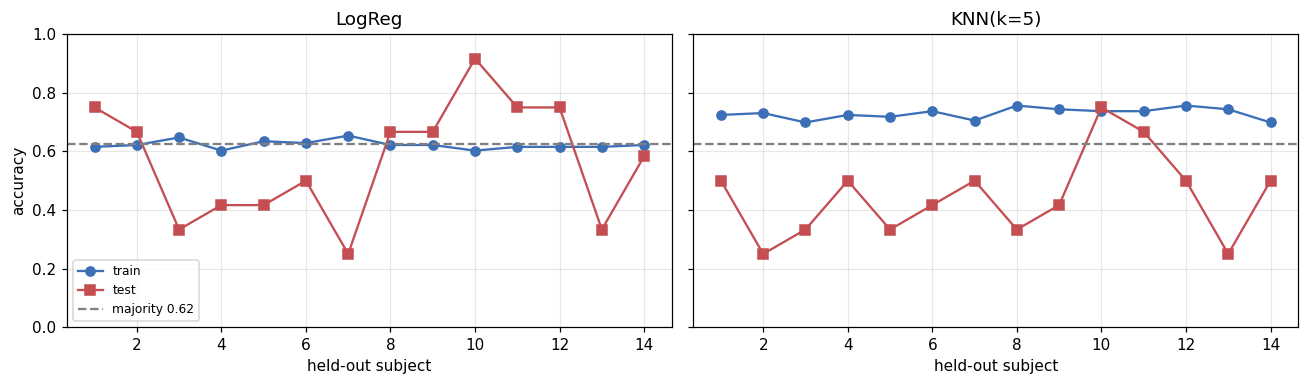

LogReg: test acc 0.571 (sd 0.198), range [0.25, 0.92]
KNN(k=5): test acc 0.446 (sd 0.145), range [0.25, 0.75]


In [18]:
# Per-fold train vs test accuracy (robustness picture), one panel per model
fig, axes = plt.subplots(1,2, figsize=(12,3.6), sharey=True)
subj = test_acc["LogReg"].index
for ax,name in zip(axes, models):
    ax.plot(subj, train_acc[name].values, "o-", label="train", color="#3B6FB6")
    ax.plot(subj, test_acc[name].values,  "s-", label="test",  color="#C44E52")
    ax.axhline(majority, ls="--", c="grey", label=f"majority {majority:.2f}")
    ax.set_title(name); ax.set_xlabel("held-out subject"); ax.set_ylim(0,1)
axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

for name in models:
    te=test_acc[name]
    print(f"{name}: test acc {te.mean():.3f} (sd {te.std():.3f}), range [{te.min():.2f}, {te.max():.2f}]")

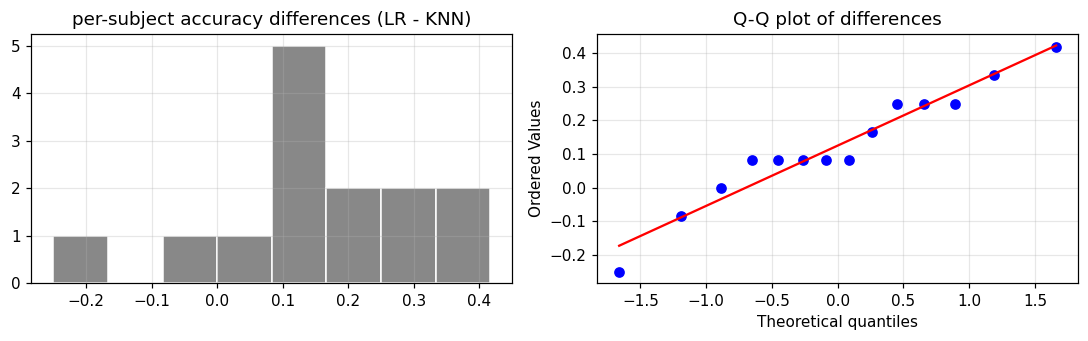

Shapiro-Wilk on differences: W=0.955, p=0.634 (approx. normal)
            Quantity            Value
         t-statistic            2.716
             p-value           0.0176
mean diff (LR - KNN)           +0.125
              95% CI [+0.026, +0.224]

Wilcoxon signed-rank: p=0.019
McNemar exact (pooled OOF): p=0.005  (b=37, c=16)


In [19]:
a = test_acc["LogReg"]; b = test_acc["KNN(k=5)"]; d = a - b

# Normality check of the per-subject differences
fig,ax = plt.subplots(1,2, figsize=(10,3.2))
ax[0].hist(d, bins=8, color="#888", edgecolor="white"); ax[0].set_title("per-subject accuracy differences (LR - KNN)")
probplot(d, plot=ax[1]); ax[1].set_title("Q-Q plot of differences")
plt.tight_layout(); plt.show()
print(f"Shapiro-Wilk on differences: W={shapiro(d).statistic:.3f}, p={shapiro(d).pvalue:.3f} "
      f"({'approx. normal' if shapiro(d).pvalue>0.05 else 'non-normal'})")

# Paired t-test with t-based 95% CI
t_stat, p_t = ttest_rel(a, b)
se = d.std(ddof=1)/np.sqrt(len(d)); q = tdist.ppf(.975, len(d)-1)
ci = (d.mean()-q*se, d.mean()+q*se)
tab = pd.DataFrame({"Quantity":["t-statistic","p-value","mean diff (LR - KNN)","95% CI"],
                    "Value":[f"{t_stat:.3f}", f"{p_t:.4f}", f"{d.mean():+.3f}", f"[{ci[0]:+.3f}, {ci[1]:+.3f}]"]})
print(tab.to_string(index=False))

# Backups
print(f"\nWilcoxon signed-rank: p={wilcoxon(a,b).pvalue:.3f}")

# McNemar uden statsmodels — scipy binom exact
from scipy.stats import binom
cl=(oof['LogReg']==y); ck=(oof['KNN(k=5)']==y)
b_mc = int(np.sum(cl & ~ck))   # LR right, KNN wrong
c_mc = int(np.sum(~cl & ck))   # LR wrong, KNN right
p_mc = 2 * binom.cdf(min(b_mc, c_mc), b_mc + c_mc, 0.5)
print(f"McNemar exact (pooled OOF): p={p_mc:.3f}  (b={b_mc}, c={c_mc})")

In [20]:
# Spearman correlations underpinning the "weak signal" point
print("Spearman corr(frustration, feature):")
for f in feat_cols:
    r,p = spearmanr(df[f], df.Frustrated); print(f"  {f:10s} rho={r:+.3f} p={p:.3f}")

Spearman corr(frustration, feature):
  HR_Mean    rho=+0.123 p=0.112
  HR_Median  rho=+0.089 p=0.251
  HR_std     rho=+0.179 p=0.020
  HR_Min     rho=-0.002 p=0.974
  HR_Max     rho=+0.181 p=0.019


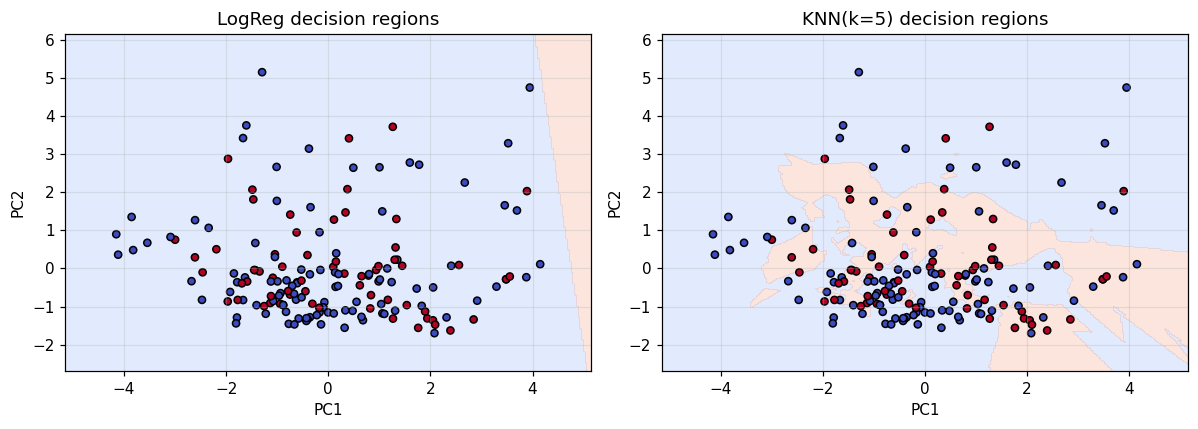

Blue = not elevated (0-2), red = elevated (>2). Heavy overlap = weak separability.


In [25]:

Zt = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
xx,yy = np.meshgrid(np.linspace(Zt[:,0].min()-1,Zt[:,0].max()+1,300),
                    np.linspace(Zt[:,1].min()-1,Zt[:,1].max()+1,300))
grid = np.c_[xx.ravel(), yy.ravel()]
fig,axes = plt.subplots(1,2, figsize=(11,4))
for ax,(name,clf) in zip(axes, {"LogReg":LogisticRegression(max_iter=2000),
                                "KNN(k=5)":KNeighborsClassifier(5)}.items()):
    clf.fit(Zt, y)
    ax.contourf(xx,yy, clf.predict(grid).reshape(xx.shape), alpha=.25, cmap="coolwarm", levels=1)
    ax.scatter(Zt[:,0],Zt[:,1], c=y, cmap="coolwarm", edgecolor="k", s=22)
    ax.set_title(f"{name} decision regions"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()
print("Blue = not elevated (0-2), red = elevated (>2). Heavy overlap = weak separability.")